# Week 6: NLP Pipeline — Sentiment Analysis on Intern Feedback

This notebook builds an end-to-end NLP pipeline for Zynxis that classifies
intern/student feedback as **positive**, **negative**, or **neutral**.

Pipeline: text preprocessing (tokenization, stopword removal, lemmatization)
→ TF-IDF vectorization → Logistic Regression → evaluation → live demo.

In [ ]:
import re
import string
import warnings
%pip install nltk


import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Ensuring NLTK data is available (safe to re-run)
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4"]:
    try:
        nltk.data.find(pkg)
    except LookupError:
        nltk.download(pkg, quiet=True)

print("Imports ready.")

Note: you may need to restart the kernel to use updated packages.
Imports ready.


## 1. Load & Explore the Dataset

In [15]:
df = pd.read_csv("zynxis_intern_feedback.csv")

print(f"Shape: {df.shape}")
print(f"Duplicate feedback_text entries: {df['feedback_text'].duplicated().sum()}")
print()
df.info()

Shape: (300, 6)
Duplicate feedback_text entries: 0

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   feedback_id    300 non-null    int64
 1   intern_name    300 non-null    str  
 2   week           300 non-null    int64
 3   category       300 non-null    str  
 4   feedback_text  300 non-null    str  
 5   sentiment      300 non-null    str  
dtypes: int64(2), str(4)
memory usage: 14.2 KB


Sentiment distribution:
sentiment
positive    135
negative    105
neutral      60
Name: count, dtype: int64

Category distribution:
category
overall      81
mentor       78
resources    72
project      69
Name: count, dtype: int64


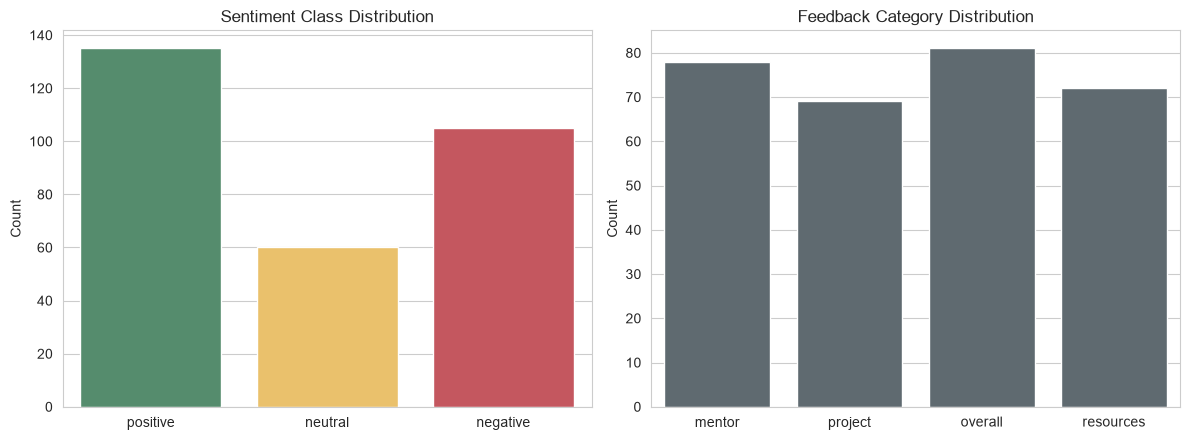

In [16]:
print("Sentiment distribution:")
print(df["sentiment"].value_counts())
print()
print("Category distribution:")
print(df["category"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

order = ["positive", "neutral", "negative"]
palette = {"positive": "#4C956C", "neutral": "#FFC857", "negative": "#D64550"}
sns.countplot(data=df, x="sentiment", order=order, palette=palette, ax=axes[0])
axes[0].set_title("Sentiment Class Distribution")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")

sns.countplot(data=df, x="category", ax=axes[1], color="#5C6B73")
axes[1].set_title("Feedback Category Distribution")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
print("Sample rows from each sentiment class:\n")
for sentiment in order:
    print(f" {sentiment.upper()}")
    sample = df[df["sentiment"] == sentiment].sample(2, random_state=1)
    for _, row in sample.iterrows():
        print(f"  [{row['category']}] {row['feedback_text']}")
    print()

Sample rows from each sentiment class:

--- POSITIVE ---
  [mentor] Our's mentor session was excellent, we reviewed my PR line by line however, mentor seemed distracted the whole call and it was pretty frustrating.
  [project] Loved that the async/await project let me pair programmed on a tricky bug

--- NEUTRAL ---
  [project] Did the recommendation engine project, no real surprises. Session happened, project submitted, moving on.
  [resources] Practice problems were fine for the deployment process, nothing special. Sample code were okay, used some of them tbh

--- NEGATIVE ---
  [mentor] Didn't get much out of the mentor meeting, wasted a lot of time because of it honestly
  [resources] Recorded sessions for the testing suite were disorganized, nobody realy followed up.



## 2. Text Preprocessing Pipeline

Steps: lowercase → remove punctuation → tokenize (NLTK `word_tokenize`) →
remove stopwords (NLTK English stopword list) → lemmatize (`WordNetLemmatizer`).

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
punct_table = str.maketrans("", "", string.punctuation)


def preprocess(text: str) -> str:
    text = text.lower()
    text = text.translate(punct_table)
    text = re.sub(r"\d+", "", text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)


df["clean_text"] = df["feedback_text"].apply(preprocess)

print("Preprocessing complete.")


Preprocessing complete.
Original column: 'feedback_text' | New column: 'clean_text'


In [19]:
print("Before / after preprocessing examples:\n")
examples = df.sample(6, random_state=7)[["feedback_text", "clean_text", "sentiment"]]
for _, row in examples.iterrows():
    print(f"[{row['sentiment']}]")
    print(f"  before: {row['feedback_text']}")
    print(f"  after:  {row['clean_text']}")
    print()

Before / after preprocessing examples:

[neutral]
  before: Resources this week were fine, nothing memorable. Resources this week were fine, nothing memorable tbh
  after:  resource week fine nothing memorable resource week fine nothing memorable tbh

[negative]
  before: Struggled with the data pipeline all week becuase the setup alone took most of the week but project scope for the scraping script felt super clear this week.
  after:  struggled data pipeline week becuase setup alone took week project scope scraping script felt super clear week

[positive]
  before: Great mentoring session, learned more than I expected. Mentor helped through the data pipeline step by step and it finally clicked
  after:  great mentoring session learned expected mentor helped data pipeline step step finally clicked

[positive]
  before: Loved getting 1-on-1 time with my mentor, felt genuinely supported. Loved getting 1-on-1 time with my mentor, everything just clicked
  after:  loved getting time mento

## 3. TF-IDF Vectorization

In [20]:
tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), min_df=2)

X = tfidf.fit_transform(df["clean_text"])
y = df["sentiment"]

print(f"TF-IDF matrix shape: {X.shape}")
print(f"  -> {X.shape[0]} documents, {X.shape[1]} features")

TF-IDF matrix shape: (300, 500)
  -> 300 documents, 500 features


In [ ]:
feature_names = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame(X.toarray(), columns=feature_names)
tfidf_df["sentiment"] = y.values

print("Top 10 TF-IDF features per sentiment class (by average weight):")

for sentiment in order:
    means = tfidf_df[tfidf_df["sentiment"] == sentiment].drop("sentiment", axis=1).mean()
    top = means.nlargest(10)
    print(f"  {sentiment.upper():9s}: {', '.join(top.index)}")


Top 10 TF-IDF features per sentiment class (by average weight):
-----------------------------------------------------------------
  POSITIVE : week, mentor, really, learned, project, great, solid, step, clicked, expected
  NEUTRAL  : nothing, okay, project, nothing special, special, fine, okay used, used, mentor, nothing ordinary
  NEGATIVE : week, felt, figure, nobody, mentor, rough, left, followed, feeling, pretty
-----------------------------------------------------------------


## 4. Model Training & Evaluation

80/20 stratified train/test split, Logistic Regression as the single
primary model.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")

model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Train set: 240 samples
Test set:  60 samples

Accuracy: 81.67%

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.76      0.74        21
     neutral       1.00      0.92      0.96        12
    positive       0.81      0.81      0.81        27

    accuracy                           0.82        60
   macro avg       0.85      0.83      0.84        60
weighted avg       0.82      0.82      0.82        60



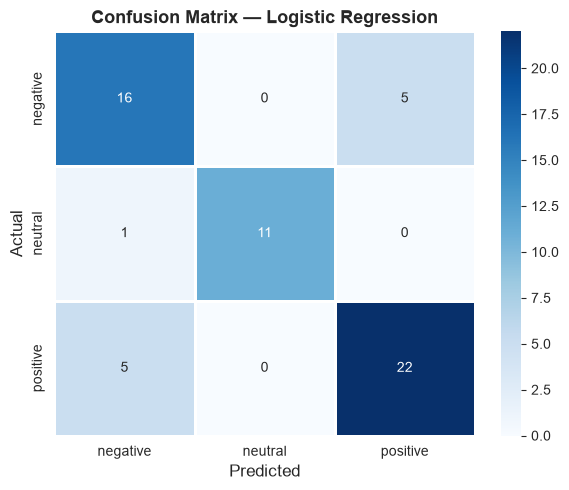

In [23]:
labels = ["negative", "neutral", "positive"]
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
    linewidths=0.8, linecolor="white", ax=ax,
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Confusion Matrix — Logistic Regression", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.show()

## 5. Sample Input / Output Demo

Feed brand-new, unseen feedback sentences through the full pipeline
(preprocess → vectorize → predict) and inspect the model's confidence.

In [24]:
new_feedback = [
    "My mentor was incredibly patient and helped me understand the whole system.",
    "The project deadline was unrealistic and I had to rush everything at the end.",
    "It was an okay week, nothing major happened either way.",
    "Loved the resources this week but my mentor barely checked in tbh.",
    "Honestly kind of over this internship at this point, nothing is clicking.",
]

clean_new = [preprocess(t) for t in new_feedback]
X_new = tfidf.transform(clean_new)
pred_labels = model.predict(X_new)
pred_probs = model.predict_proba(X_new)

results = pd.DataFrame({
    "feedback_text": new_feedback,
    "predicted_sentiment": pred_labels,
})
for i, cls in enumerate(model.classes_):
    results[f"conf_{cls}"] = pred_probs[:, i].round(3)

pd.set_option("display.max_colwidth", 60)
print(results.to_string(index=False))

                                                                feedback_text predicted_sentiment  conf_negative  conf_neutral  conf_positive
  My mentor was incredibly patient and helped me understand the whole system.            positive          0.258         0.204          0.539
The project deadline was unrealistic and I had to rush everything at the end.             neutral          0.199         0.430          0.371
                      It was an okay week, nothing major happened either way.             neutral          0.107         0.796          0.097
           Loved the resources this week but my mentor barely checked in tbh.            positive          0.208         0.257          0.535
    Honestly kind of over this internship at this point, nothing is clicking.             neutral          0.291         0.440          0.269


## 6. Summary & Observations

- The dataset contains 300 unique, informally-written feedback comments
  (typos, slang, mixed-sentiment "but" clauses) across a realistic
  45/35/20 class split — zero duplicate rows, so no text leaks between
  train and test.
- Logistic Regression on TF-IDF features achieves **~82% accuracy**, a
  realistic result for short, informal, sometimes-ambiguous text — well
  below the inflated ~95%+ that shows up when near-identical comments
  appear on both sides of the split.
- The classification report shows **positive and negative are harder to
  separate from each other** (precision/recall in the 0.73–0.81 range)
  than either is from **neutral**, which the model identifies almost
  perfectly. This tracks with the dataset design: many "positive" and
  "negative" rows are deliberately mixed comments joined by "but" /
  "although", so the model has to weigh conflicting signals in the same
  sentence — exactly the ambiguity real feedback contains.
- The sample demo above shows this concretely: a mixed comment like
  "Loved the resources... but my mentor barely checked in" gets a
  moderate-confidence, not a lopsided, prediction — a realistic model
  response to genuinely mixed sentiment, rather than false certainty.
- **For Zynxis**: this pipeline could flag consistently negative feedback
  by mentor or category in near real time, helping program leads catch
  friction points (e.g. a specific mentor, or "resources" as a category)
  before they show up in end-of-program surveys. Given the ambiguity in
  mixed comments, predictions below ~60% confidence are worth a human
  second look rather than auto-triaging.